In [1]:
import pandas as pd
import numpy as np

In [2]:
!pip install openpyxl

In [3]:
df = pd.read_excel("Individual Assignment Data File Electronic_sales.xlsx", engine = "openpyxl")

In [4]:
df.head()

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56


In [5]:
df.shape
df.columns.tolist()

['Customer ID',
 'Age',
 'Gender',
 'Loyalty Member',
 'Product Type',
 'SKU',
 'Rating',
 'Order Status',
 'Payment Method',
 'Total Price',
 'Unit Price',
 'Quantity',
 'Purchase Date',
 'Shipping Type',
 'Add-ons Purchased',
 'Add-on Total']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Customer ID        20000 non-null  int64         
 1   Age                20000 non-null  int64         
 2   Gender             19999 non-null  object        
 3   Loyalty Member     20000 non-null  object        
 4   Product Type       20000 non-null  object        
 5   SKU                20000 non-null  object        
 6   Rating             20000 non-null  int64         
 7   Order Status       20000 non-null  object        
 8   Payment Method     20000 non-null  object        
 9   Total Price        20000 non-null  float64       
 10  Unit Price         20000 non-null  float64       
 11  Quantity           20000 non-null  int64         
 12  Purchase Date      20000 non-null  datetime64[ns]
 13  Shipping Type      20000 non-null  object        
 14  Add-on

There are missing values in gender and add-ons purchased. If we look at the number of add-ons total, we will notice that some add-ons are not purchased so we will assign 'None' to these values. We will assign 'Unknown' to the missing gender value.

In [7]:
df['Gender'] = df['Gender'].fillna("Unknown").astype(str).str.strip()

In [8]:
df['Gender'].isna().sum()

np.int64(0)

In [9]:
df['Add-ons Purchased'] = df['Add-ons Purchased'].fillna('None').astype(str).str.strip()
df['Add-ons Purchased'].isna().sum()

np.int64(0)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Customer ID        20000 non-null  int64         
 1   Age                20000 non-null  int64         
 2   Gender             20000 non-null  object        
 3   Loyalty Member     20000 non-null  object        
 4   Product Type       20000 non-null  object        
 5   SKU                20000 non-null  object        
 6   Rating             20000 non-null  int64         
 7   Order Status       20000 non-null  object        
 8   Payment Method     20000 non-null  object        
 9   Total Price        20000 non-null  float64       
 10  Unit Price         20000 non-null  float64       
 11  Quantity           20000 non-null  int64         
 12  Purchase Date      20000 non-null  datetime64[ns]
 13  Shipping Type      20000 non-null  object        
 14  Add-on

We have handled missing data.Now moving on to the standardization of the columns such as loyalty member, payment method etc. 

In [11]:
df['Payment Method'].value_counts()

Payment Method
Credit Card      5868
Bank Transfer    3371
PayPal           3284
Paypal           2514
Cash             2492
Debit Card       2471
Name: count, dtype: int64

In [12]:
#checking all the columns values for standardization before fixing everything 

cat_cols = ['Gender', 'Loyalty Member', 'Product Type', 'Order Status', 'Payment Method', 'Shipping Type', 'Add-ons Purchased' ]
id_cols = ['SKU']

for c in cat_cols:
    print('\n--', c, '---')
    print(df[c].value_counts(dropna=False).head(20))



-- Gender ---
Gender
Male       10164
Female      9835
Unknown        1
Name: count, dtype: int64

-- Loyalty Member ---
Loyalty Member
No     15657
Yes     4343
Name: count, dtype: int64

-- Product Type ---
Product Type
Smartphone    5978
Tablet        4104
Laptop        3973
Smartwatch    3934
Headphones    2011
Name: count, dtype: int64

-- Order Status ---
Order Status
Completed    13432
Cancelled     6568
Name: count, dtype: int64

-- Payment Method ---
Payment Method
Credit Card      5868
Bank Transfer    3371
PayPal           3284
Paypal           2514
Cash             2492
Debit Card       2471
Name: count, dtype: int64

-- Shipping Type ---
Shipping Type
Standard     6725
Express      3366
Overnight    3357
Same Day     3280
Expedited    3272
Name: count, dtype: int64

-- Add-ons Purchased ---
Add-ons Purchased
None                                    4868
Extended Warranty                       1701
Accessory                               1680
Impulse Item                   

In [13]:
# payment method and add-ons purchased needs to be fixed there are duplicated values.

df['Payment Method'] = df['Payment Method'].astype(str).str.strip()
pm = df['Payment Method'].str.lower()
df["Payment Method"] = pm.replace({
    "paypal": "PayPal",
    "credit card": "Credit Card",
    "debit card": "Debit Card",
    "bank transfer": "Bank Transfer",
    "cash": "Cash"
})

df['Payment Method'].value_counts()

Payment Method
Credit Card      5868
PayPal           5798
Bank Transfer    3371
Cash             2492
Debit Card       2471
Name: count, dtype: int64

In [14]:

# Lets keep the original
df["Add-ons Purchased Raw"] = df["Add-ons Purchased"].copy()

CANON = {
    "accessory": "Accessory",
    "extended warranty": "Extended Warranty",
    "impulse item": "Impulse Item",
    "none": "None"
}

def standardize_addons_keep_dupes(x):
    if pd.isna(x):
        return "None"
    x = str(x).strip()
    if x == "" or x.lower() == "none":
        return "None"

    # "A, B" or "A,B" -> remove the space after comma for split
    x = x.replace(", ", ",")
    parts = [p.strip() for p in x.split(",") if p.strip()]

    # normalize the pieces (case + extra space)
    out_parts = []
    for p in parts:
        p_low = " ".join(p.lower().split())  # clear extra spaces
        out_parts.append(CANON.get(p_low, p.strip()))

    # keeping the consecutive purchased add-ons
    return ", ".join(out_parts)

df["Add-ons Purchased"] = df["Add-ons Purchased"].apply(standardize_addons_keep_dupes)

# Control
df["Add-ons Purchased"].value_counts().head(25)


Add-ons Purchased
None                                                  4868
Extended Warranty                                     1701
Accessory                                             1680
Impulse Item                                          1645
Impulse Item, Accessory                                603
Impulse Item, Impulse Item                             600
Extended Warranty, Impulse Item                        590
Accessory, Impulse Item                                578
Extended Warranty, Extended Warranty                   557
Accessory, Accessory                                   551
Impulse Item, Extended Warranty                        540
Extended Warranty, Accessory                           538
Accessory, Extended Warranty                           530
Accessory, Impulse Item, Extended Warranty             215
Impulse Item, Impulse Item, Impulse Item               204
Impulse Item, Extended Warranty, Extended Warranty     203
Accessory, Impulse Item, Accessory    

In [15]:
#lets double check the other categorical columns as well. I decided to standardize everything lower case. It will be easier for the upcoming steps

df['Gender'] = df['Gender']. astype(str).str.strip().str.lower()
df['Loyalty Member'] = df['Loyalty Member'].astype(str).str.strip().str.lower()
df['Product Type'] = df['Product Type'].astype(str).str.strip().str.lower()
df['Order Status'] = df['Order Status'].astype(str).str.strip().str.lower()
df['Payment Method'] = df['Payment Method'].astype(str).str.strip().str.lower()
df['Shipping Type'] = df['Shipping Type'].astype(str).str.strip().str.lower()
df['Add-ons Purchased'] = df['Add-ons Purchased'].astype(str).str.strip().str.lower()



In [16]:
print(df["Payment Method"].value_counts())
print(df["Shipping Type"].value_counts())
print(df["Order Status"].value_counts())
print(df["Loyalty Member"].value_counts())
print(df["Add-ons Purchased"].value_counts().head(15))


Payment Method
credit card      5868
paypal           5798
bank transfer    3371
cash             2492
debit card       2471
Name: count, dtype: int64
Shipping Type
standard     6725
express      3366
overnight    3357
same day     3280
expedited    3272
Name: count, dtype: int64
Order Status
completed    13432
cancelled     6568
Name: count, dtype: int64
Loyalty Member
no     15657
yes     4343
Name: count, dtype: int64
Add-ons Purchased
none                                          4868
extended warranty                             1701
accessory                                     1680
impulse item                                  1645
impulse item, accessory                        603
impulse item, impulse item                     600
extended warranty, impulse item                590
accessory, impulse item                        578
extended warranty, extended warranty           557
accessory, accessory                           551
impulse item, extended warranty                

Now we move on to the analysis part. Our first objective will be related with Loyalty change. We will create 2 new values sign up/cancel to understand loyalty patterns. Loyalty yes/no values will not provide us much info. We need changes over time, therefore we will analyze the patterns before sign-up/cancel and after sign-up/cancel.

In [17]:

# 1. We are sorting the values first 
df = df.sort_values(["Customer ID", "Purchase Date"]).reset_index(drop=True)

# 2. Find the Loyalty info in previous shopping 
df["prev_loyalty"] = df.groupby("Customer ID")["Loyalty Member"].shift(1)

# 3. Create the label
df["loyalty_change"] = np.select(
    [
        (df["prev_loyalty"] == "no") & (df["Loyalty Member"] == "yes"),
        (df["prev_loyalty"] == "yes") & (df["Loyalty Member"] == "no"),
    ],
    ["signup", "cancel"],
    default="no_change"
)

# 4. Event table
events = df[df["loyalty_change"].isin(["signup", "cancel"])].copy()

print("Event counts:\n", events["loyalty_change"].value_counts())
events[["Customer ID", "Purchase Date", "prev_loyalty", "Loyalty Member", "loyalty_change"]].head(10)


Event counts:
 loyalty_change
cancel    1377
signup    1344
Name: count, dtype: int64


,Customer ID,Purchase Date,prev_loyalty,Loyalty Member,loyalty_change
3,1002,2024-08-09,no,yes,signup
9,1006,2024-01-01,no,yes,signup
16,1014,2024-05-18,no,yes,signup
22,1019,2024-07-21,no,yes,signup
37,1035,2024-03-25,no,yes,signup
41,1038,2024-07-29,no,yes,signup
42,1038,2024-08-17,yes,no,cancel
64,1060,2024-01-29,yes,no,cancel
66,1061,2024-05-21,yes,no,cancel
69,1063,2024-07-08,yes,no,cancel


In [18]:
events.groupby("loyalty_change")["Customer ID"].nunique()

loyalty_change
cancel    1353
signup    1328
Name: Customer ID, dtype: int64

In [19]:
events["event_month"] = events["Purchase Date"].dt.to_period("M").astype(str)

monthly_events = (
    events.groupby(["event_month", "loyalty_change"])
          .size()
          .reset_index(name="count")
          .sort_values("event_month")
)

monthly_events.head(12)


,event_month,loyalty_change,count
0,2023-10,cancel,15
1,2023-10,signup,9
2,2023-11,cancel,15
3,2023-11,signup,19
4,2023-12,cancel,42
5,2023-12,signup,36
6,2024-01,cancel,55
7,2024-01,signup,57
8,2024-02,cancel,69
9,2024-02,signup,80


In [20]:
#we are creating the same table based on unique customers

monthly_unique = (
    events.groupby(["event_month", "loyalty_change"])["Customer ID"]
          .nunique()
          .reset_index(name="unique_customers")
          .sort_values(["event_month","loyalty_change"])
)
monthly_unique.head(12)



,event_month,loyalty_change,unique_customers
0,2023-10,cancel,15
1,2023-10,signup,9
2,2023-11,cancel,15
3,2023-11,signup,19
4,2023-12,cancel,42
5,2023-12,signup,36
6,2024-01,cancel,55
7,2024-01,signup,57
8,2024-02,cancel,69
9,2024-02,signup,80


As a next step :, I conduct an event-study analysis to quantify how customer behaviour changes around loyalty status transitions. For each customer who signs up (no to yes) or cancels (yes to no), I define an event date as the transaction date where the change occurs. I then compare key behavioural metrics in a fixed time window before and after the event (±60 days), including purchase frequency (number of transactions), average order value (mean Total Price), add-on attachment rate (share of transactions with add-ons), and order cancellation rate (share of cancelled orders). By focusing on within-customer changes around the transition date, this approach reduces bias from static differences between loyalty and non-loyalty customers and provides clearer evidence on whether loyalty transitions are associated with meaningful behavioural shifts. 

In [21]:

WINDOW_DAYS = 60

# 1. Flags (lowercase)
df["is_cancelled"] = (df["Order Status"] == "cancelled").astype(int)
df["has_addon"] = (df["Add-ons Purchased"] != "none").astype(int)

# 2. Event dataframe (signup/cancel rows)
events = df[df["loyalty_change"].isin(["signup", "cancel"])][
    ["Customer ID", "Purchase Date", "loyalty_change"]
].copy()

events = events.rename(columns={"Purchase Date": "event_date"})

def summarize_window(tx):
    """Calculates the KPIs within the window."""
    if len(tx) == 0:
        return {
            "tx_count": 0,
            "aov": np.nan,
            "addon_rate": np.nan,
            "cancel_rate": np.nan
        }
    return {
        "tx_count": len(tx),
        "aov": tx["Total Price"].mean(),
        "addon_rate": tx["has_addon"].mean(),
        "cancel_rate": tx["is_cancelled"].mean()
    }

def event_study(df_all, events_df, event_type, window_days=60):
    """Calculates pre/post metrics for a certain event type (signup/cancel)."""
    ev = events_df[events_df["loyalty_change"] == event_type].copy()
    rows = []

    for cust_id, event_date in ev[["Customer ID", "event_date"]].itertuples(index=False):
        cust_tx = df_all[df_all["Customer ID"] == cust_id]

        pre = cust_tx[
            (cust_tx["Purchase Date"] < event_date) &
            (cust_tx["Purchase Date"] >= event_date - pd.Timedelta(days=window_days))
        ]

        post = cust_tx[
            (cust_tx["Purchase Date"] >= event_date) &
            (cust_tx["Purchase Date"] < event_date + pd.Timedelta(days=window_days))
        ]

        pre_s = summarize_window(pre)
        post_s = summarize_window(post)

        rows.append({
            "Customer ID": cust_id,
            "event_type": event_type,
            "event_date": event_date,

            "pre_tx": pre_s["tx_count"],
            "post_tx": post_s["tx_count"],

            "pre_aov": pre_s["aov"],
            "post_aov": post_s["aov"],

            "pre_addon_rate": pre_s["addon_rate"],
            "post_addon_rate": post_s["addon_rate"],

            "pre_cancel_rate": pre_s["cancel_rate"],
            "post_cancel_rate": post_s["cancel_rate"],
        })

    out = pd.DataFrame(rows)

    # Delta (post - pre)
    out["delta_tx"] = out["post_tx"] - out["pre_tx"]
    out["delta_aov"] = out["post_aov"] - out["pre_aov"]
    out["delta_addon_rate"] = out["post_addon_rate"] - out["pre_addon_rate"]
    out["delta_cancel_rate"] = out["post_cancel_rate"] - out["pre_cancel_rate"]

    return out

# 3) Run event study
signup_effect = event_study(df, events, "signup", WINDOW_DAYS)
cancel_effect = event_study(df, events, "cancel", WINDOW_DAYS)

print("Signup rows:", len(signup_effect))
print("Cancel rows:", len(cancel_effect))

signup_effect.head()


Signup rows: 1344
Cancel rows: 1377


,Customer ID,event_type,event_date,pre_tx,post_tx,pre_aov,post_aov,pre_addon_rate,post_addon_rate,pre_cancel_rate,post_cancel_rate,delta_tx,delta_aov,delta_addon_rate,delta_cancel_rate
0,1002,signup,2024-08-09,0,1,NaN,3164.76,NaN,1.0,NaN,0.0,1,NaN,NaN,NaN
1,1006,signup,2024-01-01,0,1,NaN,4175.64,NaN,0.0,NaN,0.0,1,NaN,NaN,NaN
2,1014,signup,2024-05-18,0,1,NaN,4747.14,NaN,1.0,NaN,0.0,1,NaN,NaN,NaN
3,1019,signup,2024-07-21,0,1,NaN,844.83,NaN,1.0,NaN,1.0,1,NaN,NaN,NaN
4,1035,signup,2024-03-25,0,1,NaN,62.25,NaN,1.0,NaN,0.0,1,NaN,NaN,NaN


In [22]:
#summary table 

def summary_table(effect_df):
    return pd.Series({
        "n_customers": effect_df["Customer ID"].nunique(),

        "median_delta_tx": effect_df["delta_tx"].median(),
        "mean_delta_tx": effect_df["delta_tx"].mean(),

        "median_delta_aov": effect_df["delta_aov"].median(),
        "mean_delta_aov": effect_df["delta_aov"].mean(),

        "median_delta_addon_rate": effect_df["delta_addon_rate"].median(),
        "mean_delta_addon_rate": effect_df["delta_addon_rate"].mean(),

        "median_delta_cancel_rate": effect_df["delta_cancel_rate"].median(),
        "mean_delta_cancel_rate": effect_df["delta_cancel_rate"].mean(),
    })

signup_summary = summary_table(signup_effect)
cancel_summary = summary_table(cancel_effect)

summary_df = pd.DataFrame({
    "signup": signup_summary,
    "cancel": cancel_summary
})

summary_df


,signup,cancel
n_customers,1328.000000,1353.000000
median_delta_tx,1.000000,1.000000
mean_delta_tx,0.669643,0.681917
median_delta_aov,224.180000,103.750000
mean_delta_aov,170.281017,106.145954
median_delta_addon_rate,0.000000,0.000000
mean_delta_addon_rate,-0.026917,0.051115
median_delta_cancel_rate,0.000000,0.000000
mean_delta_cancel_rate,-0.011419,0.032083


Now we will plot the changes. We first start with AOV(Average Order Value) sign-up.

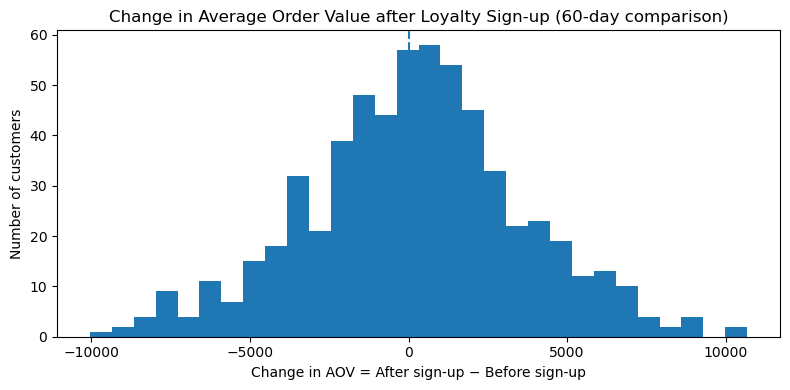

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(signup_effect["delta_aov"].dropna(),bins=30)
plt.axvline(0, linestyle= "--")
plt.title("Change in Average Order Value after Loyalty Sign-up (60-day comparison)")
plt.xlabel("Change in AOV = After sign-up − Before sign-up")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()


Now moving on to the AOV cancellation. Although there is a shift towards positive in cancellations, the shift is very little compared to sign-ups.

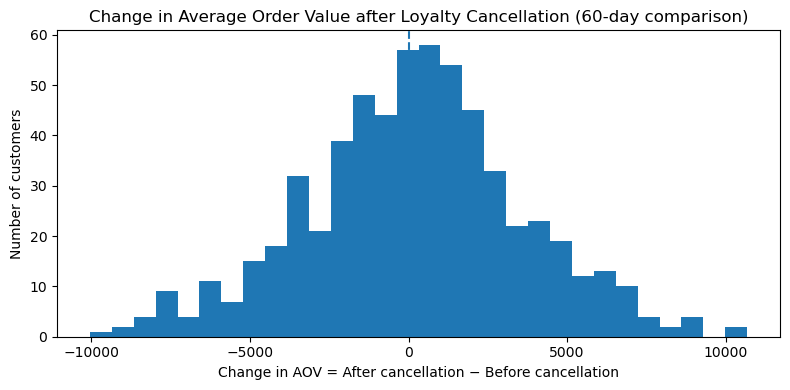

In [24]:
plt.figure(figsize=(8,4))
plt.hist(signup_effect["delta_aov"].dropna(),bins=30)
plt.axvline(0,linestyle= "--")
plt.title("Change in Average Order Value after Loyalty Cancellation (60-day comparison)")
plt.xlabel("Change in AOV = After cancellation − Before cancellation")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()


Moving on to the cancellation rate : Sign-up

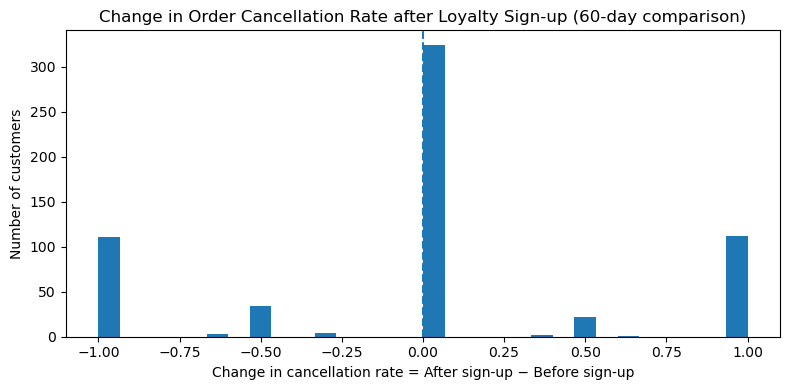

In [25]:
plt.figure(figsize=(8,4))
plt.hist(signup_effect["delta_cancel_rate"].dropna(), bins=30)
plt.axvline(0, linestyle="--")
plt.title("Change in Order Cancellation Rate after Loyalty Sign-up (60-day comparison)")
plt.xlabel("Change in cancellation rate = After sign-up − Before sign-up")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()

Moving on to the cancellation rate: Cancel

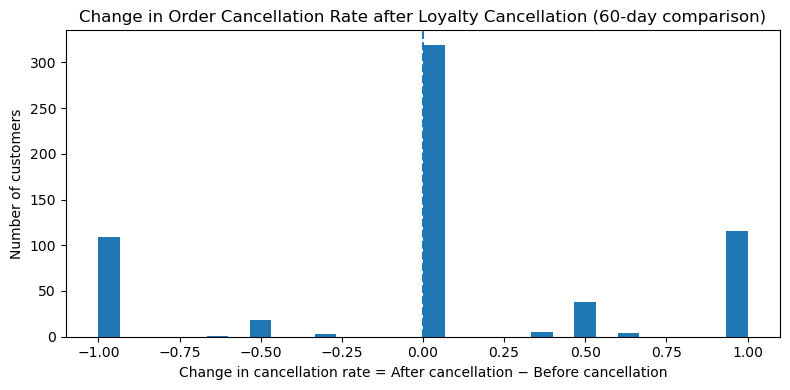

In [26]:
plt.figure(figsize=(8,4))
plt.hist(cancel_effect["delta_cancel_rate"].dropna(), bins=30)
plt.axvline(0, linestyle="--")
plt.title("Change in Order Cancellation Rate after Loyalty Cancellation (60-day comparison)")
plt.xlabel("Change in cancellation rate = After cancellation − Before cancellation")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()

Building a Logistic Regression Model to understand what factors affect Cancellations. Target variable will be,  y=1 if loyalty_change= Cancel , y=0 prev_loyalty= yes , loyalty_change is not 'Cancel'. We will use pre-window (before loyalty cancellation occurs) to understand the factors causing loyalty cancellation. 

In [27]:
#importing the libraries for logistic regression

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix


In [28]:
#checking the date and sorting again just to make sure - we have already done the sorting above but double checking

df['Purchase Date'] = pd.to_datetime(df['Purchase Date'], errors = 'coerce')
df = df.sort_values(['Customer ID', 'Purchase Date']).reset_index(drop=True)

In [29]:
#cancel event rows

# cancel event rows (correct)
cancel_events = df.loc[df["loyalty_change"] == "cancel", ["Customer ID", "Purchase Date"]].copy()

# first cancellation date per unique customer. #first cancellation date for unique customers (We are taking unique customers into the model. This is more efficient than taking all the transactions that same customer is creating. The same customer transaction can be in the 
#training and test set at the same time, which might create bias that we don't want to.)
cancel_events = (
    cancel_events
    .sort_values(["Customer ID", "Purchase Date"])
    .drop_duplicates("Customer ID", keep="first")
    .rename(columns={"Purchase Date": "event_date"})
)

print("Unique cancel customers:", cancel_events["Customer ID"].nunique())
cancel_events.head(10)


Unique cancel customers: 1353


,Customer ID,event_date
42,1038,2024-08-17
64,1060,2024-01-29
66,1061,2024-05-21
69,1063,2024-07-08
84,1079,2024-09-15
97,1096,2024-05-15
104,1101,2023-10-25
117,1115,2024-09-10
123,1120,2024-02-25
129,1124,2024-09-05


In [30]:
#we are creating y=0 control cohort 

# 1.Cancel customer id set
cancel_ids = set(cancel_events["Customer ID"].unique())

# 2.Ever-loyalty members (at least 1 time yes)
member_ids = set(df.loc[df["Loyalty Member"] == "yes", "Customer ID"].unique())

# 3.Control = member but not cancelled
control_ids = list(member_ids - cancel_ids)

print("Unique loyalty members (ever yes):", len(member_ids))
print("Unique control customers (member & never cancel):", len(control_ids))

# 4.Reference date: last purchase date when loyalty=yes 
control_events = (
    df.loc[(df["Customer ID"].isin(control_ids)) & (df["Loyalty Member"] == "yes"),
           ["Customer ID", "Purchase Date"]]
    .sort_values(["Customer ID", "Purchase Date"])
    .groupby("Customer ID", as_index=False)["Purchase Date"]
    .max()
    .rename(columns={"Purchase Date": "event_date"})
)

print("Control events rows:", len(control_events))
control_events.head(10)


Unique loyalty members (ever yes): 3834
Unique control customers (member & never cancel): 2481
Control events rows: 2481


,Customer ID,event_date
0,1002,2024-08-09
1,1003,2024-05-21
2,1006,2024-06-25
3,1014,2024-05-18
4,1016,2024-07-07
5,1019,2024-07-21
6,1021,2024-03-20
7,1035,2024-03-25
8,1036,2024-01-28
9,1040,2023-10-16


Now we will check 60 days prior the event_date and generate KPIs from that. 
Pre-window features (X):
-pre_tx = # of transactions
-pre_aov = avg total price
-pre_addon_rate = add-on ratio (has_addon mean)
-pre_cancel_rate = order cancellation ratio (is_cancelled mean)

Target (y):
cancel cohort: y_cancel = 1
control cohort: y_cancel = 0
Note: df["is_cancelled"] and df["has_addon"] has alreadt generated above EDA part. We will add a control line just in-case. 

In [31]:
WINDOW_DAYS = 60

# For safety: if there is flag do not touch, if there is no flag generate a flag
if "is_cancelled" not in df.columns:
    df["is_cancelled"] = (df["Order Status"] == "cancelled").astype(int)

if "has_addon" not in df.columns:
    df["has_addon"] = (df["Add-ons Purchased"] != "none").astype(int)


def build_pre_features(events_df, label):
    rows = []

    for cid, event_date in events_df[["Customer ID", "event_date"]].itertuples(index=False):
        start = event_date - pd.Timedelta(days=WINDOW_DAYS)

        pre = df[
            (df["Customer ID"] == cid) &
            (df["Purchase Date"] >= start) &
            (df["Purchase Date"] < event_date)
        ]

        # if pre-window empty: there is no feature - we will remove the customer from the model
        if len(pre) == 0:
            continue

        rows.append({
            "Customer ID": cid,
            "event_date": event_date,
            "y_cancel": label,

            "pre_tx": len(pre),
            "pre_aov": pre["Total Price"].mean(),
            "pre_addon_rate": pre["has_addon"].mean(),
            "pre_cancel_rate": pre["is_cancelled"].mean(),
            "Age": pre["Age"].iloc[0],
            "Gender": pre["Gender"].iloc[0],
        })

    return pd.DataFrame(rows)


# 1. Cancel cohort features
cancel_feat = build_pre_features(cancel_events, label=1)

# 2. Control cohort features
control_feat = build_pre_features(control_events, label=0)

print("Cancel_feat rows:", len(cancel_feat))
print("Control_feat rows:", len(control_feat))

cancel_feat.head(5)


Cancel_feat rows: 598
Control_feat rows: 468


,Customer ID,event_date,y_cancel,pre_tx,pre_aov,pre_addon_rate,pre_cancel_rate,Age,Gender
0,1038,2024-08-17,1,2,4646.565,0.5,0.0,56,female
1,1060,2024-01-29,1,1,1482.180,1.0,0.0,72,male
2,1079,2024-09-15,1,1,3164.760,1.0,0.0,64,male
3,1101,2023-10-25,1,1,207.500,1.0,0.0,33,female
4,1134,2023-12-22,1,1,6329.520,1.0,0.0,23,male


In [32]:
#control checks

print("NaN check (cancel):\n", cancel_feat[["pre_tx","pre_aov","pre_addon_rate","pre_cancel_rate"]].isna().sum())
print("NaN check (control):\n", control_feat[["pre_tx","pre_aov","pre_addon_rate","pre_cancel_rate"]].isna().sum())

print("Gender values:", pd.concat([cancel_feat["Gender"], control_feat["Gender"]]).value_counts().head(10))


NaN check (cancel):
 pre_tx             0
pre_aov            0
pre_addon_rate     0
pre_cancel_rate    0
dtype: int64
NaN check (control):
 pre_tx             0
pre_aov            0
pre_addon_rate     0
pre_cancel_rate    0
dtype: int64
Gender values: Gender
male      576
female    490
Name: count, dtype: int64


Our customer number dropped rapidly to Cancel_feat rows: 598, Control_feat rows: 468. Because we tried to 
identify 60 days before the purchase day and saw that many customers did not have transactions in these 60 days. We will increase the window and try to increase our sample size for the model. 

In [33]:
WINDOW_DAYS = 120

cancel_feat_120 = build_pre_features(cancel_events, label=1)
control_feat_120 = build_pre_features(control_events, label=0)

print("Cancel_feat_120 rows:", len(cancel_feat_120))
print("Control_feat_120 rows:", len(control_feat_120))

# NaN control
print("NaN check (cancel 120):\n", cancel_feat_120[["pre_tx","pre_aov","pre_addon_rate","pre_cancel_rate"]].isna().sum())
print("NaN check (control 120):\n", control_feat_120[["pre_tx","pre_aov","pre_addon_rate","pre_cancel_rate"]].isna().sum())

cancel_feat_120.head(5)


Cancel_feat_120 rows: 971
Control_feat_120 rows: 797
NaN check (cancel 120):
 pre_tx             0
pre_aov            0
pre_addon_rate     0
pre_cancel_rate    0
dtype: int64
NaN check (control 120):
 pre_tx             0
pre_aov            0
pre_addon_rate     0
pre_cancel_rate    0
dtype: int64


,Customer ID,event_date,y_cancel,pre_tx,pre_aov,pre_addon_rate,pre_cancel_rate,Age,Gender
0,1038,2024-08-17,1,2,4646.565,0.5,0.0,56,female
1,1060,2024-01-29,1,1,1482.180,1.0,0.0,72,male
2,1063,2024-07-08,1,1,1855.840,0.0,0.0,64,male
3,1079,2024-09-15,1,1,3164.760,1.0,0.0,64,male
4,1101,2023-10-25,1,1,207.500,1.0,0.0,33,female


We managed to increase our sample size critically. We will use 120 days window for the model. Now merging everything in one table. 

In [34]:
# Combine into one model table
model_df_120 = pd.concat([cancel_feat_120, control_feat_120], ignore_index=True)

print(model_df_120.shape)
print(model_df_120["y_cancel"].value_counts())

model_df_120.head()


(1768, 9)
y_cancel
1    971
0    797
Name: count, dtype: int64


,Customer ID,event_date,y_cancel,pre_tx,pre_aov,pre_addon_rate,pre_cancel_rate,Age,Gender
0,1038,2024-08-17,1,2,4646.565,0.5,0.0,56,female
1,1060,2024-01-29,1,1,1482.180,1.0,0.0,72,male
2,1063,2024-07-08,1,1,1855.840,0.0,0.0,64,male
3,1079,2024-09-15,1,1,3164.760,1.0,0.0,64,male
4,1101,2023-10-25,1,1,207.500,1.0,0.0,33,female


In [35]:
#checking whether there are any duplications after the concat

model_df_120.duplicated().sum()
model_df_120['Customer ID'].duplicated().sum()
model_df_120['Customer ID'].value_counts().head(10)

cancel_set = set(cancel_feat_120["Customer ID"])
control_set = set(control_feat_120["Customer ID"])

len(cancel_set & control_set)


0

Before moving to the logistic regression model we will check correlations. If there are any highly correlated variables, we need to remove them from the model.

In [36]:
#running correlation only on numeric values 


num_cols = ["pre_tx", "pre_aov", "pre_addon_rate", "pre_cancel_rate", "Age"]

corr = model_df_120[num_cols].corr()
corr


,pre_tx,pre_aov,pre_addon_rate,pre_cancel_rate,Age
pre_tx,1.000000,0.009799,-0.009294,0.006508,-0.000708
pre_aov,0.009799,1.000000,-0.002582,0.034552,-0.038210
pre_addon_rate,-0.009294,-0.002582,1.000000,-0.021834,0.015766
pre_cancel_rate,0.006508,0.034552,-0.021834,1.000000,0.008304
Age,-0.000708,-0.038210,0.015766,0.008304,1.000000


In [37]:
abs_corr = corr.abs()
THRESH = 0.85

upper = abs_corr.where(np.triu(np.ones(abs_corr.shape), k=1).astype(bool))
high_pairs = upper.stack().sort_values(ascending=False)

print("Top correlations:\n", high_pairs.head(10))
print("\nHighly correlated (>= 0.85):\n", high_pairs[high_pairs >= THRESH])


Top correlations:
 pre_aov          Age                0.038210
                 pre_cancel_rate    0.034552
pre_addon_rate   pre_cancel_rate    0.021834
                 Age                0.015766
pre_tx           pre_aov            0.009799
                 pre_addon_rate     0.009294
pre_cancel_rate  Age                0.008304
pre_tx           pre_cancel_rate    0.006508
pre_aov          pre_addon_rate     0.002582
pre_tx           Age                0.000708
dtype: float64

Highly correlated (>= 0.85):
 Series([], dtype: float64)


We do not have highly correlated values. We can start encoding the categorical variables and build the logistic regression.

In [38]:

# Target
y = model_df_120["y_cancel"].astype(int)

# Features
num_cols = ["pre_tx", "pre_aov", "pre_addon_rate", "pre_cancel_rate", "Age"]
cat_cols = ["Gender"]

X = model_df_120[num_cols + cat_cols].copy()

# Train/Test split (80 train/ 20 test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Preprocess: numeric -> standardize, categorical -> one-hot
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

# Logistic regression
lr = LogisticRegression(class_weight="balanced", max_iter=2000)

pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", lr)
])

# Fit
pipe.fit(X_train, y_train)

# Predict + evaluate
proba = pipe.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print("Confusion matrix:\n", confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))


ROC-AUC: 0.4765625
Confusion matrix:
 [[ 73  87]
 [102  92]]
              precision    recall  f1-score   support

           0       0.42      0.46      0.44       160
           1       0.51      0.47      0.49       194

    accuracy                           0.47       354
   macro avg       0.47      0.47      0.46       354
weighted avg       0.47      0.47      0.47       354



Building the odds-ratio table

In [39]:
# Feature names after encoding
ohe = pipe.named_steps["prep"].named_transformers_["cat"]
cat_names = ohe.get_feature_names_out(cat_cols).tolist()

feature_names = num_cols + cat_names
coefs = pipe.named_steps["model"].coef_.ravel()

or_df = pd.DataFrame({
    "feature": feature_names,
    "coef": coefs,
    "odds_ratio": np.exp(coefs)
}).sort_values("odds_ratio", ascending=False)

or_df


,feature,coef,odds_ratio
5,Gender_female,0.066648,1.068920
3,pre_cancel_rate,0.006204,1.006223
1,pre_aov,-0.004515,0.995495
4,Age,-0.021995,0.978245
6,Gender_male,-0.064106,0.937906
0,pre_tx,-0.094690,0.909655
2,pre_addon_rate,-0.108982,0.896747


The model's predictions are quite low. This means the variables we put into the model are not enough to explain the loyalty cancel patterns. We need to insert other variables into the model and try to increase the accuracy.

In [40]:
import numpy as np
import pandas as pd

WINDOW_DAYS = 120

def mode_safe(s):
    s = s.dropna()
    if len(s) == 0:
        return np.nan
    m = s.mode()
    return m.iloc[0] if len(m) > 0 else np.nan

def build_pre_features_plus(events_df, label):
    rows = []

    for cid, event_date in events_df[["Customer ID", "event_date"]].itertuples(index=False):
        start = event_date - pd.Timedelta(days=WINDOW_DAYS)

        pre = df[
            (df["Customer ID"] == cid) &
            (df["Purchase Date"] >= start) &
            (df["Purchase Date"] < event_date)
        ]

        if len(pre) == 0:
            continue

        rows.append({
            "Customer ID": cid,
            "event_date": event_date,
            "y_cancel": label,

            # numeric pre-window KPIs
            "pre_tx": len(pre),
            "pre_aov": pre["Total Price"].mean(),
            "pre_addon_rate": pre["has_addon"].mean(),
            "pre_cancel_rate": pre["is_cancelled"].mean(),
            "Age": pre["Age"].iloc[0],

            # categorical (mode in pre-window)
            "Gender": pre["Gender"].iloc[0],
            "pre_payment_method": mode_safe(pre["Payment Method"]),
            "pre_shipping_type": mode_safe(pre["Shipping Type"]),
            "pre_product_type": mode_safe(pre["Product Type"]),
        })

    return pd.DataFrame(rows)

# New feature tables
cancel_feat_plus = build_pre_features_plus(cancel_events, label=1)
control_feat_plus = build_pre_features_plus(control_events, label=0)

print("cancel_feat_plus:", cancel_feat_plus.shape)
print("control_feat_plus:", control_feat_plus.shape)

cancel_feat_plus.head(5)


cancel_feat_plus: (971, 12)
control_feat_plus: (797, 12)


,Customer ID,event_date,y_cancel,pre_tx,pre_aov,pre_addon_rate,pre_cancel_rate,Age,Gender,pre_payment_method,pre_shipping_type,pre_product_type
0,1038,2024-08-17,1,2,4646.565,0.5,0.0,56,female,cash,overnight,smartwatch
1,1060,2024-01-29,1,1,1482.180,1.0,0.0,72,male,paypal,overnight,tablet
2,1063,2024-07-08,1,1,1855.840,0.0,0.0,64,male,paypal,standard,laptop
3,1079,2024-09-15,1,1,3164.760,1.0,0.0,64,male,paypal,overnight,smartphone
4,1101,2023-10-25,1,1,207.500,1.0,0.0,33,female,cash,standard,smartphone


In [41]:
#quality checks

# Any missing value
print(cancel_feat_plus[["pre_payment_method","pre_shipping_type","pre_product_type"]].isna().sum())
print(control_feat_plus[["pre_payment_method","pre_shipping_type","pre_product_type"]].isna().sum())

# Checking values
print(cancel_feat_plus["pre_payment_method"].value_counts().head(5))
print(cancel_feat_plus["pre_shipping_type"].value_counts().head(5))
print(cancel_feat_plus["pre_product_type"].value_counts().head(5))


pre_payment_method    0
pre_shipping_type     0
pre_product_type      0
dtype: int64
pre_payment_method    0
pre_shipping_type     0
pre_product_type      0
dtype: int64
pre_payment_method
credit card      286
paypal           264
bank transfer    201
cash             115
debit card       105
Name: count, dtype: int64
pre_shipping_type
standard     288
expedited    191
same day     191
express      161
overnight    140
Name: count, dtype: int64
pre_product_type
smartphone    292
laptop        227
tablet        168
smartwatch    154
headphones    130
Name: count, dtype: int64


There is no N/A value in newly added categorical values. Now we can build our logistic regression model again with the newly added variables.

In [42]:

# 1. Combine model table
model_df_plus = pd.concat([cancel_feat_plus, control_feat_plus], ignore_index=True)

# 2.Target
y = model_df_plus["y_cancel"].astype(int)

# 3. Features
num_cols = ["pre_tx", "pre_aov", "pre_addon_rate", "pre_cancel_rate", "Age"]
cat_cols = ["Gender", "pre_payment_method", "pre_shipping_type", "pre_product_type"]

X = model_df_plus[num_cols + cat_cols].copy()

# 4. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5.Preprocess
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols),
    ],
    remainder="drop"
)

# 6. Model
lr = LogisticRegression(class_weight="balanced", max_iter=3000)

pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", lr)
])

# 7. Fit + evaluation
pipe.fit(X_train, y_train)

proba = pipe.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print("Confusion matrix:\n", confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))


ROC-AUC: 0.4793170103092783
Confusion matrix:
 [[71 89]
 [99 95]]
              precision    recall  f1-score   support

           0       0.42      0.44      0.43       160
           1       0.52      0.49      0.50       194

    accuracy                           0.47       354
   macro avg       0.47      0.47      0.47       354
weighted avg       0.47      0.47      0.47       354



The model accuracy is still very low. This indicates that these variables cannot explain the loyalty cancellations. 

Moving on to the other objective. We will try to answer "Where do cancellations concentrate and what drives them? This objective will be seperated into 2 sections. 

-We are starting with the first section. We will observe order cancellations right after the loyalty cancellations and do segmentation. 

We will work with 60 days after event date (post-window) and try to group post_payment_method, post_shipping_type and post_product_type

In [43]:
#creating cancel event post-window table 

POST_WINDOW_DAYS = 60

def mode_safe(s):
    s = s.dropna()
    if len(s) == 0:
        return np.nan
    m = s.mode()
    return m.iloc[0] if len(m) > 0 else np.nan

rows = []

for cid, event_date in cancel_events[["Customer ID", "event_date"]].itertuples(index=False):
    post_end = event_date + pd.Timedelta(days=POST_WINDOW_DAYS)

    post = df[
        (df["Customer ID"] == cid) &
        (df["Purchase Date"] >= event_date) &
        (df["Purchase Date"] < post_end)
    ]

    # if post window is empty we cannot create segmentation- so we'll pass empty rows
    if len(post) == 0:
        continue

    rows.append({
        "Customer ID": cid,
        "event_date": event_date,
        "post_payment_method": mode_safe(post["Payment Method"]),
        "post_shipping_type": mode_safe(post["Shipping Type"]),
        "post_product_type": mode_safe(post["Product Type"]),
        "post_tx": len(post)
    })

cancel_post_segments = pd.DataFrame(rows)

print("cancel_post_segments rows:", len(cancel_post_segments))
cancel_post_segments.head(10)


cancel_post_segments rows: 1353


,Customer ID,event_date,post_payment_method,post_shipping_type,post_product_type,post_tx
0,1038,2024-08-17,debit card,express,smartphone,2
1,1060,2024-01-29,paypal,overnight,smartphone,1
2,1061,2024-05-21,paypal,express,laptop,1
3,1063,2024-07-08,credit card,express,smartphone,1
4,1079,2024-09-15,debit card,overnight,smartphone,1
5,1096,2024-05-15,cash,overnight,laptop,1
6,1101,2023-10-25,credit card,overnight,smartphone,1
7,1115,2024-09-10,debit card,standard,tablet,1
8,1120,2024-02-25,credit card,express,smartphone,1
9,1124,2024-09-05,paypal,overnight,smartphone,1


In [44]:
#checking if everything is fine 

print(cancel_post_segments[["post_payment_method","post_shipping_type","post_product_type"]].isna().sum())

print("\nTop payment methods:\n", cancel_post_segments["post_payment_method"].value_counts().head(5))
print("\nTop shipping types:\n", cancel_post_segments["post_shipping_type"].value_counts().head(5))
print("\nTop product types:\n", cancel_post_segments["post_product_type"].value_counts().head(5))


post_payment_method    0
post_shipping_type     0
post_product_type      0
dtype: int64

Top payment methods:
 post_payment_method
credit card      400
paypal           381
bank transfer    246
cash             187
debit card       139
Name: count, dtype: int64

Top shipping types:
 post_shipping_type
standard     419
express      252
expedited    235
same day     235
overnight    212
Name: count, dtype: int64

Top product types:
 post_product_type
smartphone    402
laptop        276
smartwatch    270
tablet        257
headphones    148
Name: count, dtype: int64


We'll get delta cancel rate from cancel_effect dataframe above and then we'll merge with cancel_post_segments based on Customer ID.

In [45]:
# 1. get the necessary columns from cancel_effect
cancel_delta = cancel_effect[["Customer ID", "delta_cancel_rate"]].copy()

# 2. Merge on segmentation layer
seg_df = cancel_post_segments.merge(cancel_delta, on="Customer ID", how="inner")

print("Merged rows (seg_df):", len(seg_df))
seg_df.head(5)


Merged rows (seg_df): 1377


,Customer ID,event_date,post_payment_method,post_shipping_type,post_product_type,post_tx,delta_cancel_rate
0,1038,2024-08-17,debit card,express,smartphone,2,0.0
1,1060,2024-01-29,paypal,overnight,smartphone,1,0.0
2,1061,2024-05-21,paypal,express,laptop,1,NaN
3,1063,2024-07-08,credit card,express,smartphone,1,NaN
4,1079,2024-09-15,debit card,overnight,smartphone,1,0.0


In [46]:
#grouping based on shipping type 

ship_seg = (
    seg_df.groupby("post_shipping_type")["delta_cancel_rate"]
          .agg(n_customers="count",
               mean_delta="mean",
               median_delta="median",
               q25=lambda x: x.quantile(0.25),
               q75=lambda x: x.quantile(0.75))
          .reset_index()
          .sort_values("mean_delta", ascending=False)
)

ship_seg.head(10)


,post_shipping_type,n_customers,mean_delta,median_delta,q25,q75
0,expedited,123,0.140921,0.0,0.0,0.666667
3,same day,117,0.045584,0.0,0.0,0.500000
4,standard,188,0.006206,0.0,0.0,0.000000
2,overnight,92,-0.021739,0.0,0.0,0.000000
1,express,93,-0.023297,0.0,0.0,0.000000


In [47]:
#grouping by payment method 

pay_seg = (
    seg_df.groupby("post_payment_method")["delta_cancel_rate"]
          .agg(n_customers="count",
               mean_delta="mean",
               median_delta="median",
               q25=lambda x: x.quantile(0.25),
               q75=lambda x: x.quantile(0.75))
          .reset_index()
          .sort_values("mean_delta", ascending=False)
)

pay_seg.head(10)


,post_payment_method,n_customers,mean_delta,median_delta,q25,q75
2,credit card,186,0.070789,0.0,0.0,0.5
4,paypal,170,0.060784,0.0,0.0,0.5
0,bank transfer,133,0.016291,0.0,0.0,0.5
3,debit card,54,-0.009259,0.0,0.0,0.0
1,cash,70,-0.078571,0.0,0.0,0.0


In [48]:
#group by product type 

prod_seg = (
    seg_df.groupby("post_product_type")["delta_cancel_rate"]
          .agg(n_customers="count",
               mean_delta="mean",
               median_delta="median",
               q25=lambda x: x.quantile(0.25),
               q75=lambda x: x.quantile(0.75))
          .reset_index()
          .sort_values("mean_delta", ascending=False)
)

prod_seg.head(10)


,post_product_type,n_customers,mean_delta,median_delta,q25,q75
0,headphones,83,0.154618,0.0,0.0,0.583333
4,tablet,111,0.070571,0.0,0.0,0.250000
1,laptop,136,0.044118,0.0,0.0,0.500000
2,smartphone,166,-0.013052,0.0,0.0,0.333333
3,smartwatch,117,-0.041311,0.0,0.0,0.000000


There are some NaN delta_cancel_rate values in seg_df dataframe we created above. We will drop these values so the deltas will show more accurate results. 

In [49]:
# Removing NaN deltas
seg_df_clean = seg_df.dropna(subset=["delta_cancel_rate"]).copy()

print("Before drop:", len(seg_df))
print("After drop:", len(seg_df_clean))
print("Dropped:", len(seg_df) - len(seg_df_clean))

Before drop: 1377
After drop: 613
Dropped: 764


We are grouping again based on seg_df_clean new dataframe we created above.

In [50]:
#for the shipping type 

ship_seg_clean = (
    seg_df_clean.groupby("post_shipping_type")["delta_cancel_rate"]
      .agg(n_customers="count",
           mean_delta="mean",
           median_delta="median",
           q25=lambda x: x.quantile(0.25),
           q75=lambda x: x.quantile(0.75))
      .reset_index()
      .sort_values("mean_delta", ascending=False)
)

ship_seg_clean


,post_shipping_type,n_customers,mean_delta,median_delta,q25,q75
0,expedited,123,0.140921,0.0,0.0,0.666667
3,same day,117,0.045584,0.0,0.0,0.500000
4,standard,188,0.006206,0.0,0.0,0.000000
2,overnight,92,-0.021739,0.0,0.0,0.000000
1,express,93,-0.023297,0.0,0.0,0.000000


In [51]:
#for the payment method 

pay_seg_clean = (
    seg_df_clean.groupby("post_payment_method")["delta_cancel_rate"]
      .agg(n_customers="count",
           mean_delta="mean",
           median_delta="median",
           q25=lambda x: x.quantile(0.25),
           q75=lambda x: x.quantile(0.75))
      .reset_index()
      .sort_values("mean_delta", ascending=False)
)

pay_seg_clean


,post_payment_method,n_customers,mean_delta,median_delta,q25,q75
2,credit card,186,0.070789,0.0,0.0,0.5
4,paypal,170,0.060784,0.0,0.0,0.5
0,bank transfer,133,0.016291,0.0,0.0,0.5
3,debit card,54,-0.009259,0.0,0.0,0.0
1,cash,70,-0.078571,0.0,0.0,0.0


In [52]:
#for the product type 

prod_seg_clean = (
    seg_df_clean.groupby("post_product_type")["delta_cancel_rate"]
      .agg(n_customers="count",
           mean_delta="mean",
           median_delta="median",
           q25=lambda x: x.quantile(0.25),
           q75=lambda x: x.quantile(0.75))
      .reset_index()
      .sort_values("mean_delta", ascending=False)
)

prod_seg_clean


,post_product_type,n_customers,mean_delta,median_delta,q25,q75
0,headphones,83,0.154618,0.0,0.0,0.583333
4,tablet,111,0.070571,0.0,0.0,0.250000
1,laptop,136,0.044118,0.0,0.0,0.500000
2,smartphone,166,-0.013052,0.0,0.0,0.333333
3,smartwatch,117,-0.041311,0.0,0.0,0.000000


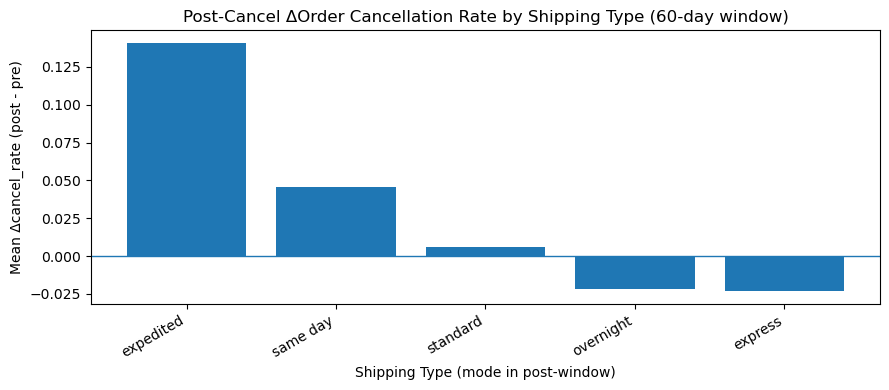

In [53]:
#plotting based on shipping type 

# Using ship_seg_clean dataframe we created above
plot_df = ship_seg_clean.sort_values("mean_delta", ascending=False)

plt.figure(figsize=(9,4))
plt.bar(plot_df["post_shipping_type"], plot_df["mean_delta"])
plt.axhline(0, linewidth=1)
plt.title("Post-Cancel ΔOrder Cancellation Rate by Shipping Type (60-day window)")
plt.xlabel("Shipping Type (mode in post-window)")
plt.ylabel("Mean Δcancel_rate (post - pre)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


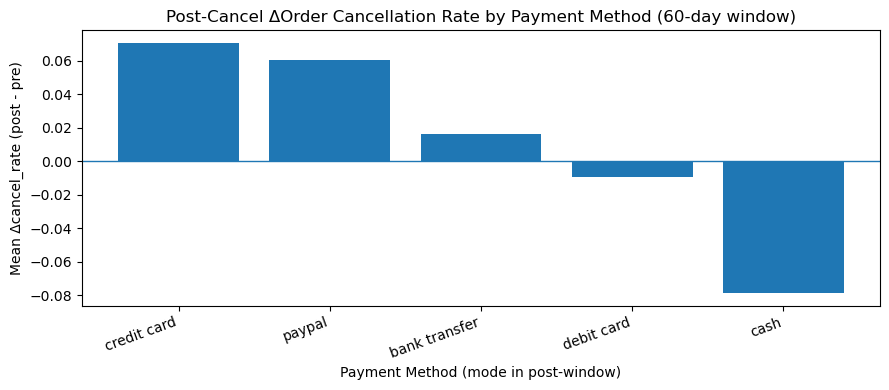

In [54]:
#plotting based on payment method 

plot_df = pay_seg_clean.sort_values("mean_delta", ascending=False)

plt.figure(figsize=(9,4))
plt.bar(plot_df["post_payment_method"], plot_df["mean_delta"])
plt.axhline(0, linewidth=1)
plt.title("Post-Cancel ΔOrder Cancellation Rate by Payment Method (60-day window)")
plt.xlabel("Payment Method (mode in post-window)")
plt.ylabel("Mean Δcancel_rate (post - pre)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


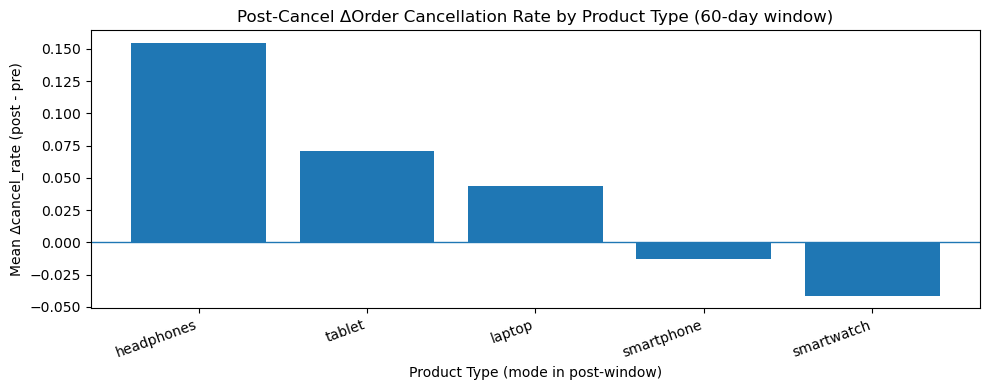

In [55]:
#plotting based on product type 

plot_df = prod_seg_clean.sort_values("mean_delta", ascending=False)

plt.figure(figsize=(10,4))
plt.bar(plot_df["post_product_type"], plot_df["mean_delta"])
plt.axhline(0, linewidth=1)
plt.title("Post-Cancel ΔOrder Cancellation Rate by Product Type (60-day window)")
plt.xlabel("Product Type (mode in post-window)")
plt.ylabel("Mean Δcancel_rate (post - pre)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


Now we are moving on to the second part of our objective, why orders are cancelled? We'll build a logistic regression to understand this. 

Instead of using add-ons purchased values, we'll use has add-on flag we inserted before. SKU might also impact the model as there will be a lot of unique values.

Target Value: 
y_order_cancel = 1 → Order Status == "cancelled"
y_order_cancel = 0 → Order Status == "completed" (or not cancelled)

In [57]:

# Target for Objective 3: order cancellation
df["y_order_cancel"] = (df["Order Status"] == "cancelled").astype(int)

print(df["y_order_cancel"].value_counts())
print(df["Order Status"].value_counts())


y_order_cancel
0    13432
1     6568
Name: count, dtype: int64
Order Status
completed    13432
cancelled     6568
Name: count, dtype: int64


In [58]:
#now we are moving on to the feature selection before running the model. We are dropping the variables that can create target leakage

# add-on flag (if there is none - generate)
if "has_addon" not in df.columns:
    df["has_addon"] = (df["Add-ons Purchased"] != "none").astype(int)

target = "y_order_cancel"

num_cols = ["Total Price", "Unit Price", "Quantity", "Rating", "Add-on Total", "Age"]
cat_cols = ["Gender", "Loyalty Member", "Product Type", "Payment Method", "Shipping Type", "has_addon"]

# only get the existing columns (to decrease the level of error)
num_cols = [c for c in num_cols if c in df.columns]
cat_cols = [c for c in cat_cols if c in df.columns]

model_tx = df[num_cols + cat_cols + [target]].copy()

print("Model table shape:", model_tx.shape)
model_tx.head()


Model table shape: (20000, 13)


,Total Price,Unit Price,Quantity,Rating,Add-on Total,Age,Gender,Loyalty Member,Product Type,Payment Method,Shipping Type,has_addon,y_order_cancel
0,5538.33,791.19,7,2,40.21,53,male,no,smartphone,credit card,standard,1,1
1,741.09,247.03,3,3,26.09,53,male,no,tablet,paypal,overnight,1,0
2,1855.84,463.96,4,3,0.00,41,male,no,laptop,credit card,express,0,0
3,3164.76,791.19,4,2,60.16,41,male,yes,smartphone,cash,overnight,1,0
4,41.50,20.75,2,5,35.56,75,male,yes,smartphone,cash,express,1,0


In [60]:
#health check to see if there is any duplicates etc. 

# We'll add the Customer ID to check if there is actually real duplicates (we'll not add this to the model)
key_cols = ["Customer ID", "Purchase Date", "SKU", "Unit Price", "Quantity", "Total Price"]

# only pick the existing ones
key_cols = [c for c in key_cols if c in df.columns]

dup_true = df.duplicated(subset=key_cols).sum()
print("Potential true duplicates (by key):", dup_true)

# check for duplicate values:
df[df.duplicated(subset=key_cols, keep=False)][key_cols + ["Order Status"]].head(10)


Potential true duplicates (by key): 0


,Customer ID,Purchase Date,SKU,Unit Price,Quantity,Total Price,Order Status


In [61]:
#Healthchecks are fine. Moving on to the correlation matrix. Only doing the correlation with numeric variables.

corr = model_tx[num_cols].corr()
corr



,Total Price,Unit Price,Quantity,Rating,Add-on Total,Age
Total Price,1.000000,0.673951,0.653872,-0.232429,0.083924,0.003096
Unit Price,0.673951,1.000000,0.006715,-0.343829,0.125189,-0.004402
Quantity,0.653872,0.006715,1.000000,-0.008587,0.003419,0.008555
Rating,-0.232429,-0.343829,-0.008587,1.000000,-0.044338,0.002949
Add-on Total,0.083924,0.125189,0.003419,-0.044338,1.000000,-0.005291
Age,0.003096,-0.004402,0.008555,0.002949,-0.005291,1.000000


It is expected that the total price is highly correlated with unit price and quantity. Because total price = unit price * quantity. So we'll drop total price from our features because it will make more sense to understand the cancellations are caused whether the price or quantity. 

In [62]:
# creating the model and dropping total_price from num_cols

target = "y_order_cancel"

# Total Price removed
num_cols = ["Unit Price", "Quantity", "Rating", "Add-on Total", "Age"]
cat_cols = ["Gender", "Loyalty Member", "Product Type", "Payment Method", "Shipping Type", "has_addon"]

X = model_tx[num_cols + cat_cols].copy()
y = model_tx[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols),
    ],
    remainder="drop"
)

lr = LogisticRegression(class_weight="balanced", max_iter=4000)

pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", lr)
])

pipe.fit(X_train, y_train)

proba = pipe.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, proba))
print("Confusion matrix:\n", confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))



ROC-AUC: 0.5077202836512906
Confusion matrix:
 [[1261 1425]
 [ 605  709]]
              precision    recall  f1-score   support

           0       0.68      0.47      0.55      2686
           1       0.33      0.54      0.41      1314

    accuracy                           0.49      4000
   macro avg       0.50      0.50      0.48      4000
weighted avg       0.56      0.49      0.51      4000



Since the data is synthetic, the customers/orders are very random rather than relational. That's why, we are suffering to increase the accuracy. We'll go with more basic models. 

In [63]:
#building a hypothesis testing whether order cancellations are related Shipping Type / Payment Method / Product Type / Loyalty Member or independent?
#building a chi-square test

from scipy.stats import chi2_contingency

def cramers_v(table):
    # table: contingency table (DataFrame)
    chi2, p, dof, expected = chi2_contingency(table)
    n = table.to_numpy().sum()
    r, k = table.shape
    return chi2, p, dof, np.sqrt((chi2 / n) / (min(r-1, k-1)))

factors = ["Shipping Type", "Payment Method", "Product Type", "Loyalty Member"]

results = []

for col in factors:
    ct = pd.crosstab(df[col], df["y_order_cancel"])
    chi2, p, dof, v = cramers_v(ct)
    results.append({
        "factor": col,
        "chi2": chi2,
        "dof": dof,
        "p_value": p,
        "cramers_v": v,
        "n": ct.to_numpy().sum()
    })

ht_df = pd.DataFrame(results).sort_values("cramers_v", ascending=False)
ht_df



,factor,chi2,dof,p_value,cramers_v,n
1,Payment Method,8.423499,4,0.077240,0.020523,20000
0,Shipping Type,3.497512,4,0.478257,0.013224,20000
2,Product Type,0.874450,4,0.928197,0.006612,20000
3,Loyalty Member,0.010021,1,0.920262,0.000708,20000


In [64]:
# cancel rate by category (for every factor)
for col in factors:
    rate = df.groupby(col)["y_order_cancel"].mean().sort_values(ascending=False)
    print("\n", col)
    display(rate.head(10))



 Shipping Type


Shipping Type
express      0.338384
same day     0.333232
overnight    0.330652
expedited    0.324572
standard     0.321784
Name: y_order_cancel, dtype: float64


 Payment Method


Payment Method
credit card      0.335549
paypal           0.333736
bank transfer    0.329872
debit card       0.318495
cash             0.306982
Name: y_order_cancel, dtype: float64


 Product Type


Product Type
tablet        0.331140
smartphone    0.330211
smartwatch    0.329944
laptop        0.323937
headphones    0.323222
Name: y_order_cancel, dtype: float64


 Loyalty Member


Loyalty Member
no     0.328607
yes    0.327654
Name: y_order_cancel, dtype: float64

None of these factors explain cancellations. The p-values do not make sense. Cancel rates in every category is around 30%- 40% which explains why our LG model AUC value was around 0.50. 

In [65]:
#we'll build the heatmap anyway 

pivot = df.pivot_table(
    index="Shipping Type",
    columns="Payment Method",
    values="y_order_cancel",
    aggfunc="mean"
)

pivot


Payment Method,bank transfer,cash,credit card,debit card,paypal
Shipping Type,,,,,
expedited,0.335160,NaN,0.327027,NaN,0.311153
express,NaN,0.320592,0.344788,0.329298,0.357477
overnight,NaN,0.297647,0.344322,0.330211,0.351319
same day,0.332152,NaN,0.335514,NaN,0.332100
standard,0.322581,0.303249,0.332665,0.294564,0.329082


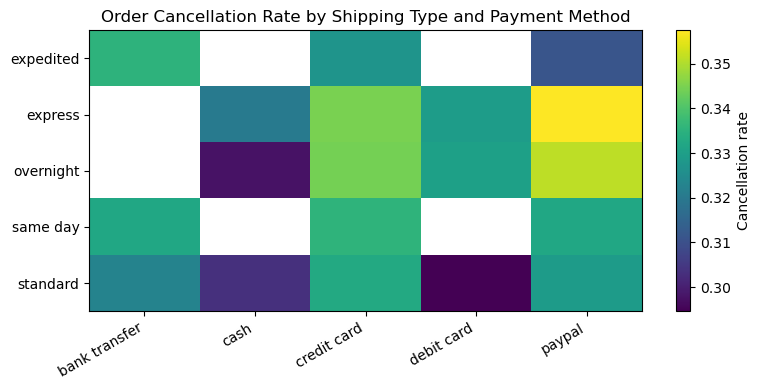

In [66]:
plt.figure(figsize=(8,4))
plt.imshow(pivot.values, aspect="auto")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=30, ha="right")
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(label="Cancellation rate")
plt.title("Order Cancellation Rate by Shipping Type and Payment Method")
plt.tight_layout()
plt.show()

This heatmap is also supporting our conclusion that cancel rate cannot be explained by operational factors in this dataset as this dataset is synthetic. We'll apply linear programming to the dataset to see with a limited budget, which sectors we can target? 

In [67]:
# creating a shipping and payment segmentation table for LP
seg_lp = (
    df.groupby(["Shipping Type", "Payment Method"])["y_order_cancel"]
      .agg(n_orders="count", cancel_rate="mean")
      .reset_index()
)

seg_lp["expected_cancels"] = seg_lp["n_orders"] * seg_lp["cancel_rate"]

seg_lp.sort_values("expected_cancels", ascending=False).head(10)


,Shipping Type,Payment Method,n_orders,cancel_rate,expected_cancels
16,standard,credit card,1996,0.332665,664.0
18,standard,paypal,1960,0.329082,645.0
11,same day,bank transfer,1129,0.332152,375.0
14,standard,bank transfer,1147,0.322581,370.0
0,expedited,bank transfer,1095,0.335160,367.0
1,expedited,credit card,1110,0.327027,363.0
12,same day,credit card,1070,0.335514,359.0
13,same day,paypal,1081,0.332100,359.0
2,expedited,paypal,1067,0.311153,332.0
6,express,paypal,856,0.357477,306.0


As a next step we will define cost/effect assumptions. If shipping type is fast, we assume it will be more costly. We need to make assumptions to create LP model because we have no information regarding cost/effect in this dataset.

cost: expedited=5, same day=4, overnight=3, express=2, standard=1

effect (% reduction in cancellations): expedited=0.06, same day=0.05, overnight=0.04, express=0.03, standard=0.02

In [68]:
# 1.Cost assumptions by shipping type
cost_map = {
    "expedited": 5,
    "same day": 4,
    "overnight": 3,
    "express": 2,
    "standard": 1
}

# 2.Effect assumptions by shipping type (expected reduction rate)
effect_map = {
    "expedited": 0.06,
    "same day": 0.05,
    "overnight": 0.04,
    "express": 0.03,
    "standard": 0.02
}

seg_lp2 = seg_lp.copy()
seg_lp2["cost"] = seg_lp2["Shipping Type"].map(cost_map)
seg_lp2["effect_rate"] = seg_lp2["Shipping Type"].map(effect_map)

# expected cancellations prevented if we choose this segment
seg_lp2["preventable_cancels"] = seg_lp2["expected_cancels"] * seg_lp2["effect_rate"]

# Efficiency metric: cancels prevented per cost unit
seg_lp2["preventable_per_cost"] = seg_lp2["preventable_cancels"] / seg_lp2["cost"]

seg_lp2.sort_values("preventable_per_cost", ascending=False).head(10)


,Shipping Type,Payment Method,n_orders,cancel_rate,expected_cancels,cost,effect_rate,preventable_cancels,preventable_per_cost
16,standard,credit card,1996,0.332665,664.0,1,0.02,13.28,13.2800
18,standard,paypal,1960,0.329082,645.0,1,0.02,12.90,12.9000
14,standard,bank transfer,1147,0.322581,370.0,1,0.02,7.40,7.4000
15,standard,cash,831,0.303249,252.0,1,0.02,5.04,5.0400
11,same day,bank transfer,1129,0.332152,375.0,4,0.05,18.75,4.6875
17,standard,debit card,791,0.294564,233.0,1,0.02,4.66,4.6600
6,express,paypal,856,0.357477,306.0,2,0.03,9.18,4.5900
4,express,credit card,873,0.344788,301.0,2,0.03,9.03,4.5150
13,same day,paypal,1081,0.332100,359.0,4,0.05,17.95,4.4875
12,same day,credit card,1070,0.335514,359.0,4,0.05,17.95,4.4875


In [70]:
#building a scenario analysis 

import numpy as np
import pandas as pd

def knapsack_01_dp(seg_table, budget):
    """
    Maximize value (preventable_cancels) subject to sum(cost) <= budget
    Each segment can be chosen at most once (0/1).
    Returns selected indices and objective value.
    """
    seg = seg_table.reset_index(drop=True).copy()
    costs = seg["cost"].astype(int).to_list()
    values = seg["preventable_cancels"].astype(float).to_list()
    n = len(seg)

    # dp[i][b] = max value using first i items with budget b
    dp = np.zeros((n + 1, budget + 1), dtype=float)
    keep = np.zeros((n + 1, budget + 1), dtype=bool)

    for i in range(1, n + 1):
        c = costs[i - 1]
        v = values[i - 1]
        for b in range(0, budget + 1):
            # not take
            best = dp[i - 1, b]
            take = -1
            if c <= b:
                take = dp[i - 1, b - c] + v
            if take > best:
                dp[i, b] = take
                keep[i, b] = True
            else:
                dp[i, b] = best

    # backtrack
    b = budget
    selected = []
    for i in range(n, 0, -1):
        if keep[i, b]:
            selected.append(i - 1)
            b -= costs[i - 1]
    selected.reverse()

    return selected, float(dp[n, budget])

def solve_scenarios(seg_table, budgets):
    summary_rows = []
    selected_dict = {}

    for B in budgets:
        idx, obj = knapsack_01_dp(seg_table, B)
        sel = seg_table.iloc[idx][[
            "Shipping Type","Payment Method","n_orders","expected_cancels",
            "cost","effect_rate","preventable_cancels","preventable_per_cost"
        ]].sort_values("preventable_cancels", ascending=False)

        summary_rows.append({
            "budget": B,
            "objective_prevented": obj,
            "budget_used": int(sel["cost"].sum()) if len(sel) else 0,
            "n_segments_selected": int(len(sel))
        })

        selected_dict[B] = sel

    return pd.DataFrame(summary_rows), selected_dict

# Run DP scenarios
budgets = [10, 20, 30]
summary_df, selected_dict = solve_scenarios(seg_lp2, budgets)

summary_df


,budget,objective_prevented,budget_used,n_segments_selected
0,10,66.55,10,6
1,20,111.48,20,9
2,30,155.28,30,11


In [71]:
for B in [10, 20, 30]:
    print("\n=== Budget:", B, "===")
    display(selected_dict[B].head(20))



=== Budget: 10 ===


,Shipping Type,Payment Method,n_orders,expected_cancels,cost,effect_rate,preventable_cancels,preventable_per_cost
11,same day,bank transfer,1129,375.0,4,0.05,18.75,4.6875
16,standard,credit card,1996,664.0,1,0.02,13.28,13.2800
18,standard,paypal,1960,645.0,1,0.02,12.90,12.9000
6,express,paypal,856,306.0,2,0.03,9.18,4.5900
14,standard,bank transfer,1147,370.0,1,0.02,7.40,7.4000
15,standard,cash,831,252.0,1,0.02,5.04,5.0400



=== Budget: 20 ===


,Shipping Type,Payment Method,n_orders,expected_cancels,cost,effect_rate,preventable_cancels,preventable_per_cost
11,same day,bank transfer,1129,375.0,4,0.05,18.75,4.6875
12,same day,credit card,1070,359.0,4,0.05,17.95,4.4875
13,same day,paypal,1081,359.0,4,0.05,17.95,4.4875
16,standard,credit card,1996,664.0,1,0.02,13.28,13.2800
18,standard,paypal,1960,645.0,1,0.02,12.90,12.9000
6,express,paypal,856,306.0,2,0.03,9.18,4.5900
4,express,credit card,873,301.0,2,0.03,9.03,4.5150
14,standard,bank transfer,1147,370.0,1,0.02,7.40,7.4000
15,standard,cash,831,252.0,1,0.02,5.04,5.0400



=== Budget: 30 ===


,Shipping Type,Payment Method,n_orders,expected_cancels,cost,effect_rate,preventable_cancels,preventable_per_cost
0,expedited,bank transfer,1095,367.0,5,0.06,22.02,4.4040
1,expedited,credit card,1110,363.0,5,0.06,21.78,4.3560
11,same day,bank transfer,1129,375.0,4,0.05,18.75,4.6875
12,same day,credit card,1070,359.0,4,0.05,17.95,4.4875
13,same day,paypal,1081,359.0,4,0.05,17.95,4.4875
16,standard,credit card,1996,664.0,1,0.02,13.28,13.2800
18,standard,paypal,1960,645.0,1,0.02,12.90,12.9000
6,express,paypal,856,306.0,2,0.03,9.18,4.5900
4,express,credit card,873,301.0,2,0.03,9.03,4.5150
14,standard,bank transfer,1147,370.0,1,0.02,7.40,7.4000
